In [28]:
from matplotlib import pyplot as plt
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 14
})

95% CL Upper Limit (Weak Mixing): 6.15e-06 Mpc^-1


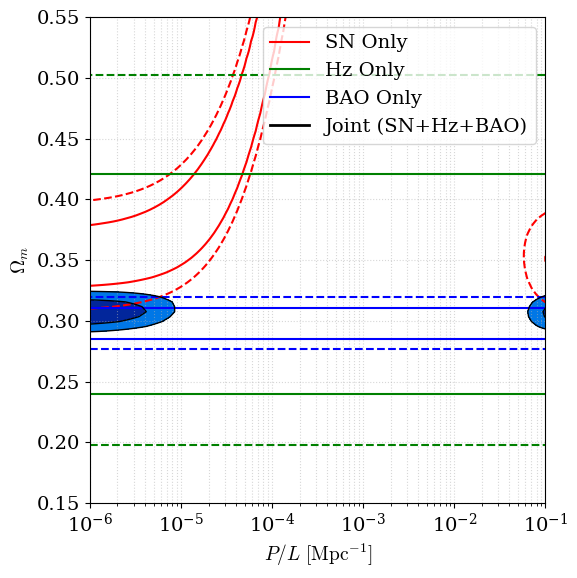

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM

# Constants and Configuration
c_light = 299792.458
om_range = np.linspace(0.15, 0.55, 100)
pl_range = np.logspace(-6.0, -1.0, 100)
h0_range = np.linspace(60, 80, 40)

# Physics Models
def get_rs_approx(H0, Om, Obh2=0.02237):
    h = H0 / 100.0
    return 147.09 * ((Om * h**2) / 0.143)**-0.35 * (Obh2 / 0.02237)**-0.12

def get_bao_theory(z, bao_type, Om, H0, rs):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    dh, dm = c_light / cosmo.H(z).value, cosmo.comoving_transverse_distance(z).value
    theory = np.zeros_like(z)
    theory[bao_type == 'DM_over_rs'], theory[bao_type == 'DH_over_rs'] = dm[bao_type == 'DM_over_rs']/rs, dh[bao_type == 'DH_over_rs']/rs
    mask_dv = (bao_type == 'DV_over_rs')
    theory[mask_dv] = (z[mask_dv] * dh[mask_dv] * dm[mask_dv]**2)**(1/3) / rs
    return theory

def get_mu_theory(z, Om, H0, PL):
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    prob = 2/3 + (1/3) * np.exp(-(PL * c_light / H0) * (cosmo.H(z).value - H0) / (Om * H0))
    return 5 * np.log10(cosmo.luminosity_distance(z).value / np.sqrt(np.maximum(prob, 1e-9))) + 25

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn, m_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
z_hz, val_hz, err_hz = np.loadtxt('data/cc.txt', unpack=True)
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
bao_inv_cov = np.linalg.inv(np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt'))

grids = {k: np.full((len(pl_range), len(om_range)), 1e9) for k in ['sn', 'hz', 'bao', 'joint']}

for i, pl in enumerate(pl_range):
    for j, om in enumerate(om_range):
        for h0 in h0_range:
            # Individual Chi2 components
            mu_model = get_mu_theory(z_sn, om, h0, pl)
            res_sn = m_obs - mu_model
            c2_sn = np.sum(res_sn**2/err_sn**2) - (np.sum(res_sn/err_sn**2)**2 / np.sum(1/err_sn**2))
            c2_hz = np.sum(((val_hz - h0 * np.sqrt(om*(1+z_hz)**3 + (1-om))) / err_hz)**2)
            dv = bao_val - get_bao_theory(z_bao, bao_type, om, h0, get_rs_approx(h0, om))
            c2_bao = dv @ bao_inv_cov @ dv
            
            # Profiling: update grids with minimum Chi2 found over h0
            grids['sn'][i, j] = min(grids['sn'][i, j], c2_sn)
            grids['hz'][i, j] = min(grids['hz'][i, j], c2_hz)
            grids['bao'][i, j] = min(grids['bao'][i, j], c2_bao)
            grids['joint'][i, j] = min(grids['joint'][i, j], c2_sn + c2_hz + c2_bao)

chi2_1d = np.min(grids['joint'], axis=1)
dchi2_1d = chi2_1d - np.min(chi2_1d)

# 2. Extract the Excluded Range (Interval)
# 找到所有 Delta Chi2 > 4.0 的索引
excluded_indices = np.where(dchi2_1d > 4.0)[0]

if len(excluded_indices) > 0:
    # 下界：区间里的第一个点
    idx_lower = excluded_indices[0]
    p_lower_limit = pl_range[idx_lower]
    
    # 上界：区间里的最后一个点
    idx_upper = excluded_indices[-1]
    p_upper_limit = pl_range[idx_upper]
    
    print(f"95% CL Excluded Range for P/L: [{p_lower_limit:.2e}, {p_upper_limit:.2e}] Mpc^-1")

plt.figure(figsize=(6, 6))
Y, X = np.meshgrid(om_range, pl_range)
lvls = [2.30, 6.17]

cs_sn = plt.contour(X, Y, grids['sn'] - np.min(grids['sn']), levels=lvls, colors='r', linestyles=['-', '--'])
cs_hz = plt.contour(X, Y, grids['hz'] - np.min(grids['hz']), levels=lvls, colors='g', linestyles=['-', '--'])
cs_bao = plt.contour(X, Y, grids['bao'] - np.min(grids['bao']), levels=lvls, colors='b', linestyles=['-', '--'])

plt.contourf(X, Y, grids['joint'] - np.min(grids['joint']), levels=[0, 2.30, 6.17], colors=[ "#02269b",'#0077e6'])
cs_j = plt.contour(X, Y, grids['joint'] - np.min(grids['joint']), levels=lvls, colors='k', linewidths=1)

plt.plot([], [], 'r-', label='SN Only')
plt.plot([], [], 'g-', label='Hz Only')
plt.plot([], [], 'b-', label='BAO Only')
plt.plot([], [], 'k-', lw=2, label='Joint (SN+Hz+BAO)')

plt.xscale('log')
plt.xlabel(r'$P/L \ [\mathrm{Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$\Omega_m$', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig('fig/pl-om.pdf')
plt.show()

In [33]:
chi2_1d = np.min(grids['joint'], axis=1)
dchi2_1d = chi2_1d - np.min(chi2_1d)

# 2. Extract the Excluded Range (Interval)
# 找到所有 Delta Chi2 > 4.0 的索引
excluded_indices = np.where(dchi2_1d > 4.0)[0]

if len(excluded_indices) > 0:
    # 下界：区间里的第一个点
    idx_lower = excluded_indices[0]
    p_lower_limit = pl_range[idx_lower]
    
    # 上界：区间里的最后一个点
    idx_upper = excluded_indices[-1]
    p_upper_limit = pl_range[idx_upper]
    
    print(f"95% CL Excluded Range for P/L: [{p_lower_limit:.2e}, {p_upper_limit:.2e}] Mpc^-1")

95% CL Excluded Range for P/L: [6.43e-06, 7.05e-02] Mpc^-1


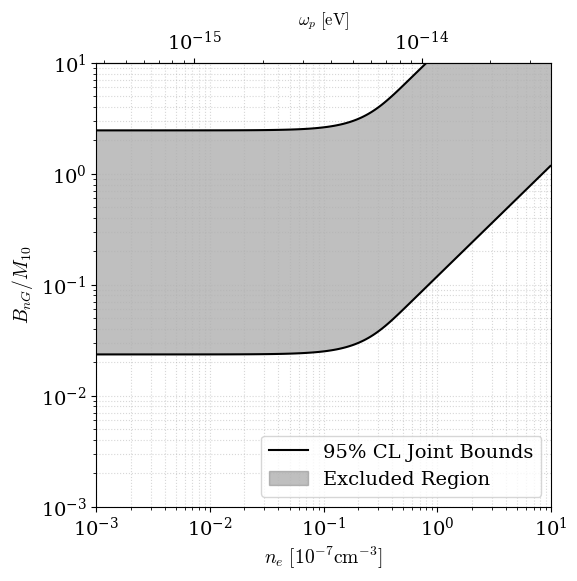

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physics constants (Natural units)
w, L = 1.5, 1.5637e29
# Recalibrated: wp ~ 1.2e-14 eV at ne = 1 (10^-7 cm^-3)
wp2_base = 1.378e-28 
bm_base = 1.95e-30

# 2. Transition probability function (Weak mixing approximation)
def get_p_weak(ne_grid, y_grid):
    """Calculates P ~ (Mixing)^2 * (Coherence) for parallel bounds"""
    wp2 = ne_grid * wp2_base
    mixing = ((2 * w * y_grid * bm_base) / wp2)**2
    delta = (wp2 * L) / (4 * w)
    coherence = 0.5 * (1 - np.exp(-2 * delta**2))
    return 0.5 * mixing * coherence

# 3. Grid and data generation
ne_ax = np.logspace(-3, 1, 200)
y_ax = np.logspace(-3, 1, 200) 
N, Y = np.meshgrid(ne_ax, y_ax)
P_vals = get_p_weak(N, Y)

# 4. Statistical limits from your joint analysis
p_low = p_lower_limit 
p_up = p_upper_limit

# 5. Visualization
fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(N, Y, P_vals, levels=[p_low, p_up], colors='gray', alpha=0.5)
ax.contour(N, Y, P_vals, levels=[p_low, p_up], colors='k', linewidths=1.5)

# Secondary top axis for Plasma Frequency wp [eV]
# ne=1 -> wp ~ 1.17e-14 eV
ax_wp = ax.secondary_xaxis('top', functions=(lambda x: np.sqrt(wp2_base * x), lambda x: x**2 / wp2_base))
ax_wp.set_xlabel(r'$\omega_p \ [\mathrm{eV}]$', fontsize=12)

# Legend and labels
ax.plot([], [], 'k-', lw=1.5, label='95% CL Joint Bounds')
ax.fill_between([], [], color='gray', alpha=0.5, label='Excluded Region')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$n_e \ [10^{-7} \mathrm{cm}^{-3}]$')
ax.set_ylabel(r'$B_{nG} / M_{10}$')
ax.legend(loc='lower right')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig('fig/bm-ne.pdf')
plt.show()

In [44]:
import numpy as np

# Your statistical result (P/L in Mpc^-1)
k_lim = 6.43e-6 

# Constants (Natural Units)
B = 1e-9 * 0.0195 # nG to eV^2
L = 1.0 * 1.56e29 # Mpc to eV^-1

# Calculation of M
# P = k * L
p = k_lim * 1.0 
m_ev = (B * L) / (2 * np.sqrt(p))
m_gev = m_ev / 1e9

# Coupling constant g (GeV^-1)
g_coupling = 1.0 / m_gev

print(f"Energy Scale M: {m_gev:.5e} GeV")
print(f"Coupling Constant g: {g_coupling:.2e} GeV^-1")

Energy Scale M: 5.99824e+11 GeV
Coupling Constant g: 1.67e-12 GeV^-1


95% CL Upper Limit for kappa: 4.53e-06 Mpc^-1


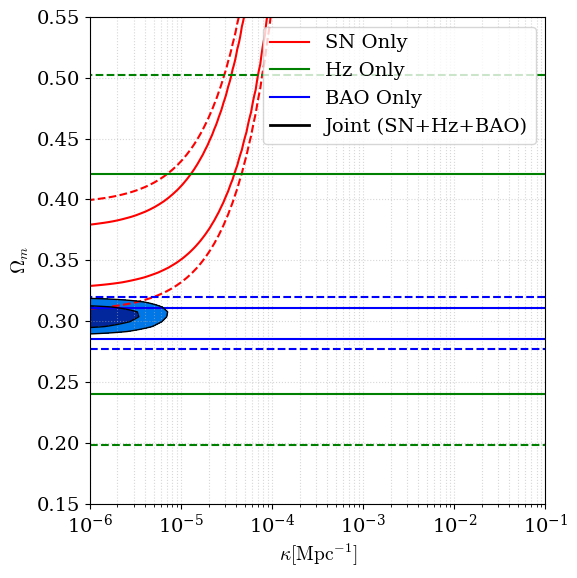

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.cosmology import FlatLambdaCDM

c_light = 299792.458
GRID_RES = 60
om_range = np.linspace(0.15, 0.55, 100)
kappa_range = np.logspace(-6.0, -1.0, 100)
h0_range = np.linspace(60, 80, 40)

def get_rs_approx(H0, Om, Obh2=0.02237):
    # Aubourg et al. 2015 approximation for rs(zd) in Mpc
    h = H0 / 100.0
    return 147.09 * ((Om * h**2) / 0.143)**-0.35 * (Obh2 / 0.02237)**-0.12

def get_bao_theory(z_array, bao_type, Om, H0, rs):
    """Calculates BAO theory vector matching data order"""
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    dh = c_light / cosmo.H(z_array).value
    dm = cosmo.comoving_transverse_distance(z_array).value
    theory = np.zeros_like(z_array)
    theory[bao_type == 'DM_over_rs'] = dm[bao_type == 'DM_over_rs'] / rs
    theory[bao_type == 'DH_over_rs'] = dh[bao_type == 'DH_over_rs'] / rs
    mask_dv = (bao_type == 'DV_over_rs')
    theory[mask_dv] = (z_array[mask_dv] * dh[mask_dv] * dm[mask_dv]**2)**(1/3) / rs
    return theory

def get_mu_theory(z, Om, H0, kappa):
    """Calculates theoretical distance modulus with cosmic opacity"""
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om)
    dL = cosmo.luminosity_distance(z).value
    # Survival probability: P = exp(-kappa * y)
    y = cosmo.comoving_distance(z).value 
    prob = np.exp(-kappa * y)
    return 5 * np.log10(dL / np.sqrt(np.maximum(prob, 1e-9))) + 25

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn, m_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
z_hz, val_hz, err_hz = np.loadtxt('data/cc.txt', unpack=True)
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
bao_inv_cov = np.linalg.inv(bao_cov)


grids = {k: np.full((len(kappa_range), len(om_range)), 1e9) for k in ['sn', 'hz', 'bao', 'joint']}
for i, kappa in enumerate(kappa_range):
    for j, om in enumerate(om_range):
        min_chi2 = 1e9
        for h0 in h0_range:
            # SN Likelihood: Analytical marginalization over MB
            mu_model = get_mu_theory(z_sn, om, h0, kappa)
            res = m_obs - mu_model
            chi2_sn = np.sum(res**2 / err_sn**2) - (np.sum(res / err_sn**2)**2 / np.sum(1.0 / err_sn**2))
            
            # Hz Likelihood
            hz_theory = h0 * np.sqrt(om*(1+z_hz)**3 + (1-om))
            chi2_hz = np.sum(((val_hz - hz_theory) / err_hz)**2)
            
            # BAO Likelihood
            rs = get_rs_approx(h0, om)
            v_theory = get_bao_theory(z_bao, bao_type, om, h0, rs)
            delta_v = bao_val - v_theory
            chi2_bao = delta_v @ bao_inv_cov @ delta_v
            
            chi2_total = chi2_sn + chi2_hz + chi2_bao
            if chi2_total < min_chi2: min_chi2 = chi2_total

            grids['sn'][i, j] = min(grids['sn'][i, j], chi2_sn)
            grids['hz'][i, j] = min(grids['hz'][i, j], chi2_hz)
            grids['bao'][i, j] = min(grids['bao'][i, j], chi2_bao)
            grids['joint'][i, j] = min(grids['joint'][i, j], chi2_sn + chi2_bao + chi2_bao)            


chi2_1d = np.min(grids['joint'], axis=1)
dchi2_1d = chi2_1d - np.min(chi2_1d)
within_95_mask = dchi2_1d <= 4.0
kappa_upper_limit = np.max(kappa_range[within_95_mask])

print(f"95% CL Upper Limit for kappa: {kappa_upper_limit:.2e} Mpc^-1")

plt.figure(figsize=(6, 6))
Y, X = np.meshgrid(om_range, kappa_range)
lvls = [2.30, 6.17]

cs_sn = plt.contour(X, Y, grids['sn'] - np.min(grids['sn']), levels=lvls, colors='r', linestyles=['-', '--'])
cs_hz = plt.contour(X, Y, grids['hz'] - np.min(grids['hz']), levels=lvls, colors='g', linestyles=['-', '--'])
cs_bao = plt.contour(X, Y, grids['bao'] - np.min(grids['bao']), levels=lvls, colors='b', linestyles=['-', '--'])

plt.contourf(X, Y, grids['joint'] - np.min(grids['joint']), levels=[0, 2.30, 6.17], colors=[ "#02269b",'#0077e6'])
cs_j = plt.contour(X, Y, grids['joint'] - np.min(grids['joint']), levels=lvls, colors='k', linewidths=1)

plt.plot([], [], 'r-', label='SN Only')
plt.plot([], [], 'g-', label='Hz Only')
plt.plot([], [], 'b-', label='BAO Only')
plt.plot([], [], 'k-', lw=2, label='Joint (SN+Hz+BAO)')

plt.xscale('log')
plt.xlabel(r'$\kappa [\mathrm{Mpc}^{-1}]$', fontsize=14)
plt.ylabel(r'$\Omega_m$', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig('fig/kappa-om.pdf')
plt.show()



# # Optional: Visualization of the 1D marginalized constraint
# plt.figure()
# plt.plot(kappa_range, dchi2_1d, 'k-', lw=2)
# plt.axhline(4.0, color='r', ls='--', label='95% CL (Delta Chi2 = 4)')
# plt.xscale('log')
# plt.xlabel(r'$\kappa \ [\mathrm{Mpc}^{-1}]$')
# plt.ylabel(r'$\Delta\chi^2$')
# plt.legend()
# plt.show()

# # 4. Result Visualization
# dchi2 = chi2_grid - np.nanmin(chi2_grid)
# Y, X = np.meshgrid(om_range, kappa_range)
# min_idx = np.unravel_index(np.nanargmin(chi2_grid), chi2_grid.shape)
# best_kappa, best_om = kappa_range[min_idx[0]], om_range[min_idx[1]]
# print("bestfit: kappa=",best_kappa,'om=',best_om)
# plt.figure(figsize=(6, 6))
# plt.contourf(X, Y, dchi2, levels=[0, 2.30, 6.17, 11.8], colors=['#1f77b4', "#7fa8de", '#aec7e8'])
# plt.contour(X, Y, dchi2, levels=[2.30, 6.17, 11.8], colors='k', linewidths=1.5)
# plt.plot(best_kappa, best_om, 'r+', markersize=10, markeredgewidth=2, label='Best Fit')
# plt.xscale('log')
# plt.ylabel(r'$\Omega_m$')
# plt.xlabel(r'$\kappa \ [\mathrm{Mpc}^{-1}]$')
# plt.title('Constraints on Opacity (SN + Hz + DESI BAO)')
# plt.grid(True, which="both", ls=":", alpha=0.4)
# plt.tight_layout()
# plt.savefig('fig/kappa-om.pdf')
# plt.show()

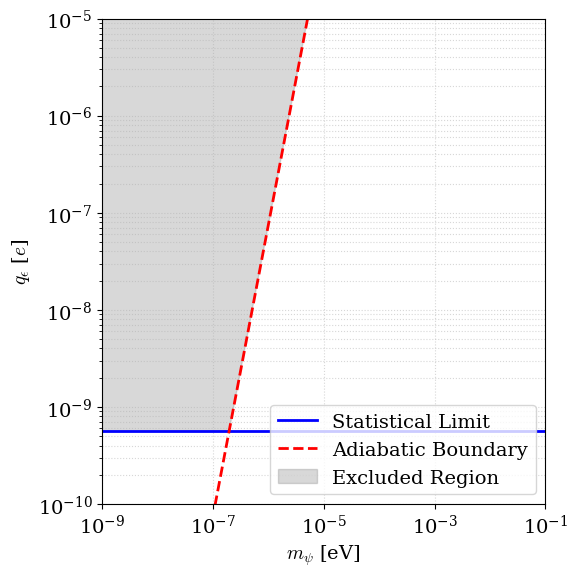

In [42]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

alpha_em = alpha_em = 7.2973525643e-3 #1.0 / 137.036
e = np.sqrt(4.0 * np.pi * alpha_em)
ev_to_mpc = 1.5637e29
gauss_to_ev2 = 0.0195354
B = 1.0 * 1e-9 * gauss_to_ev2 # 1 nG
W = 1.5 # eV
f_pol = 1.0 # Standard parallel polarization

def solve_qe_from_kappa(kappa_lim_mpc):
    """Inverts the non-perturbative formula to solve for q_epsilon"""
    kappa_ev = kappa_lim_mpc / ev_to_mpc
    c_const = (e**(8/3)) / (4.0 * gamma(1/6) * gamma(13/6))
    inner_factor = (2.0 * B**2 / (3.0 * W))**(1/3)
    return (kappa_ev / (c_const * inner_factor * f_pol))**(3/8)

# 3. Derive adiabatic boundary q_epsilon as a function of m_psi
def get_adiabatic_boundary_qe(m, ratio_threshold=1):
    """Solves q_epsilon that satisfies the adiabatic limit ratio = threshold"""
    # From (3/2) * (omega * e * qe * B / m_psi^4) = ratio_threshold
    return (ratio_threshold * 2.0 * m**3) / (3.0 * W * e * B)

# 4. Generate data for the plot
kappa_obs_limit = kappa_upper_limit # 95% CL upper bound from your fitting
qe_stat_limit = solve_qe_from_kappa(kappa_obs_limit)
m_vals = np.logspace(-9, -1, 500)
qe_adiabatic_vals = get_adiabatic_boundary_qe(m_vals)

# 5. Visualization of the boundary
plt.figure(figsize=(6, 6))
# Plot the horizontal statistical limit
plt.axhline(qe_stat_limit, color='blue', lw=2, label=r'Statistical Limit')
# Plot the adiabatic validity boundary
plt.plot(m_vals, qe_adiabatic_vals, 'r--', lw=2, label='Adiabatic Boundary')

# Fill the excluded region (where kappa > limit AND adiabaticity holds)
plt.fill_between(m_vals,  np.maximum(qe_stat_limit, qe_adiabatic_vals), 1e-4,
                 color='gray', alpha=0.3, label='Excluded Region')

plt.xscale('log'); plt.yscale('log')
plt.xlim(1e-9, 1e-1); plt.ylim(1e-10, 1e-5)
plt.xlabel(r'$m_\psi$ [eV]'); plt.ylabel(r'$q_\epsilon$ [$e$]')
plt.legend(loc='lower right')
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig('fig/qe-m.pdf')
plt.show()

In [40]:
from scipy.optimize import brentq

def diff_qe(m):
    return get_adiabatic_boundary_qe(m) - qe_stat_limit

m_intersect = brentq(diff_qe, 1e-9, 1e-1)

print("Intersection mass m_psi =", m_intersect, "eV")
print("Corresponding q_e =", qe_stat_limit)


Intersection mass m_psi = 1.9560729630606665e-07 eV
Corresponding q_e = 5.622931064336145e-10
